![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Final Project - Design

#### By: Sergi Nàcher Muñoz

## 0. Imports 

### 0.1. General libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gdsfactory as gf
import jax
import jax.example_libraries.optimizers as opt
import jax.numpy as jnp
from matplotlib.pyplot import cm

import sax
from gdsfactory.generic_tech import get_generic_pdk
from scipy import constants
from scipy.constants import c
from scipy.interpolate import interp1d

import gplugins.sax as gs
import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

from upvfab.sin300.cband import PDK, cells

/var/folders/l8/3nhlx6bj305_vfsnlb1w6_480000gn/T/ipykernel_50705/2952821180.py:13: DeprecationWarning: The 'gdsfactory.generic_tech' module is deprecated and will be removed in a future version. Please update your imports to use 'gdsfactory.gpdk' instead:
  from gdsfactory.gpdk import LAYER, LAYER_STACK, get_generic_pdk
Or for submodules:
  from gdsfactory.gpdk.layer_map import LAYER
  from gdsfactory.gpdk.layer_stack import LAYER_STACK
  from gdsfactory.generic_tech import get_generic_pdk


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import gplugins.tidy3d as gt
import gdsfactory as gf

from upvfab.sin300.cband import PDK, cells

In [3]:
nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength

### 0.2. Materials

In [4]:
si_complex = td.material_library["cSi"]["Li1993_293K"].eps_model(f)
si_index , si_k = td.Medium.eps_complex_to_nk(si_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## Part I. Design and Simulation of Individual Components 

## 1. Simulating Propagation Modes in SOI Waveguides

### 1.1. Define the SOI waveguide structure (450 nm width, 220 nm thickness). 

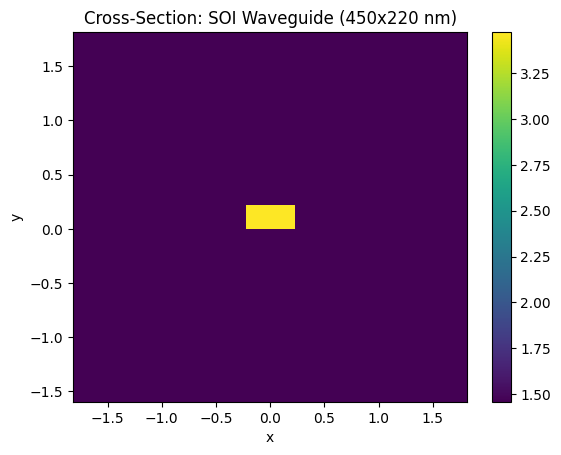

In [5]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width = 0.45, # Waveguide width
    core_thickness = 0.22, # Waveguide height 
    slab_thickness = 0,  # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material = 'si', #  Material of the waveguide
    clad_material = 'sio2', # Surrounding material
    # Modesolver Parameters
    wavelength = 1.55, # Wavelength to simulate
    num_modes = 4, # Targeted number of modes to find 
    max_grid_scaling = 1.5, # Parameters of the grid
    grid_resolution = 20, # Parameters of the grid
    cache_path = '.cache/', # Important! In order to save simulation time, set your cache Path!
    precision = 'double'
)

deep_waveguide.plot_index()
plt.title("Cross-Section: SOI Waveguide (450x220 nm)")
plt.show()

### 1.2. Simulate fundamental TE and TM modes. 

In [6]:
deep_waveguide.n_eff

2026-05-17 17:11:13.489 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_198a1ab0a96c4a6f.npz.


array([2.33508782+7.05715980e-05j, 1.7447082 +2.39341986e-04j,
       1.46251286+2.05632472e-04j, 1.43196857+2.18207211e-04j])

In [7]:
deep_waveguide.fraction_te

array([0.960726  , 0.06940437, 0.64309704, 0.99810644])

In [8]:
deep_waveguide.fraction_tm

array([0.039274  , 0.93059563, 0.35690296, 0.00189356])

Text(0.5, 1.0, 'Modo 0 - Campo Ex (Modo TE0)')

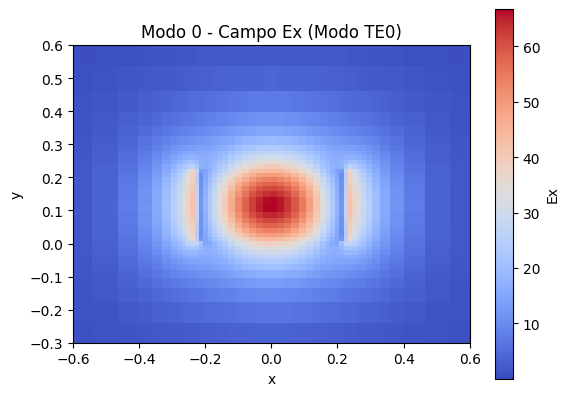

In [9]:
deep_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 0 - Campo Ex (Modo TE0)')

Text(0.5, 1.0, 'Modo 1 - Campo Ey (Modo TM0)')

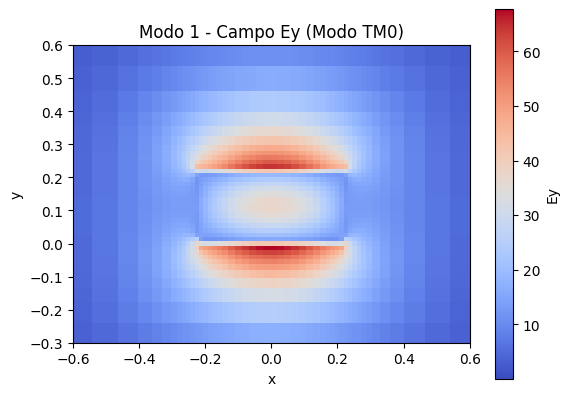

In [10]:
deep_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 1 - Campo Ey (Modo TM0)')

Para el modo fundamental TM0 se puede observar un campo poco confinado en el núcleo, y en su lugar la luz viaja por el cladding.

Ya tenemos los modos fundamentales tanto para TE como para TM. Ahora vamos a verificar que los demás modos están en corte

Text(0.5, 1.0, 'Modo 2 - Campo Ex')

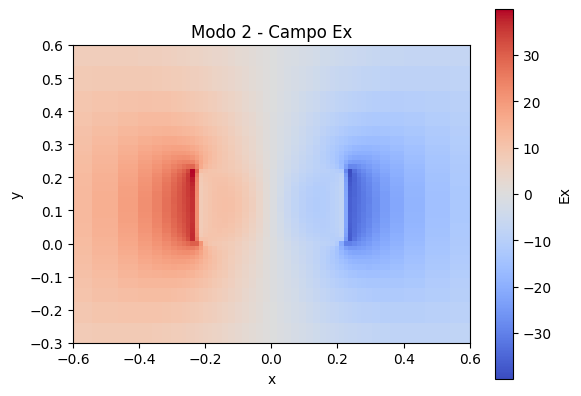

In [11]:
deep_waveguide.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 2 - Campo Ex')

Text(0.5, 1.0, 'Modo 2 - Campo Ey')

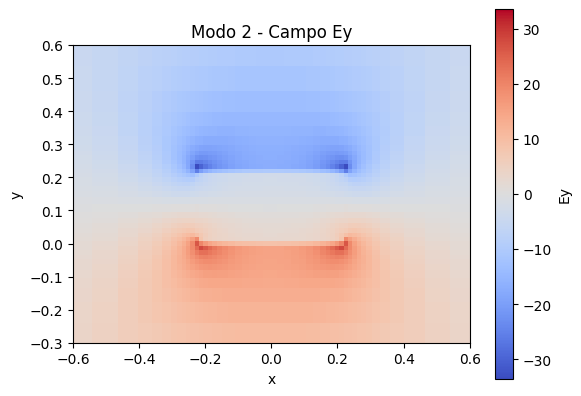

In [12]:
deep_waveguide.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 2 - Campo Ey')

Por tanto, hemos verificado que los siguientes modos estarán en corte como ya se había previsto.

### 1.3. Extract effective index (n_eff) and group index (n_g) values. 

In [13]:
# 1. Cargamos el archivo con los barridos precalculados
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

# Extraemos las columnas que nos interesan: Longitud de onda (0) y n_eff del Modo TE (3)
wvl = SOI[:, 0]
neff_te = SOI[:, 3]

# 2. Buscamos el índice exacto para la longitud de onda central (1.55 um)
indice_central = np.where(np.isclose(wvl, 1.55))[0][0]

wvl_central = wvl[indice_central]
n_eff_TE = neff_te[indice_central]

# 3. Calculamos la derivada (dn_eff / d_lambda) usando los puntos anterior y posterior
dn_eff = (neff_te[indice_central + 1] - neff_te[indice_central - 1]) / 2
delta_wvl = (wvl[indice_central + 1] - wvl[indice_central - 1]) / 2

dn_eff_dlambda = dn_eff / delta_wvl

# 4. Aplicamos la fórmula del Índice de Grupo (n_g)
n_g_TE = n_eff_TE - (wvl_central * dn_eff_dlambda)

# Mostramos los resultados por pantalla
print("--- RESULTADOS MODO FUNDAMENTAL TE ---")
print(f"n_eff TE a 1.55um: {n_eff_TE:.4f}")
print(f"n_g TE calculado:  {n_g_TE:.4f}")

--- RESULTADOS MODO FUNDAMENTAL TE ---
n_eff TE a 1.55um: 2.3558
n_g TE calculado:  4.2933


## 2. Designing Directional Couplers

### 2.1. Simulate directional couplers in GDSFactory. 

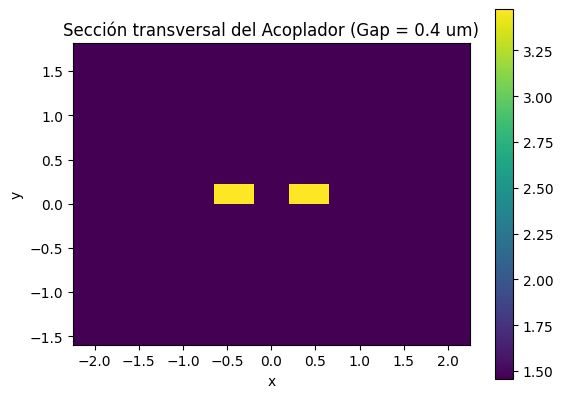

2026-05-17 17:11:13.830 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_b6c3d27b59df5e01.npz.


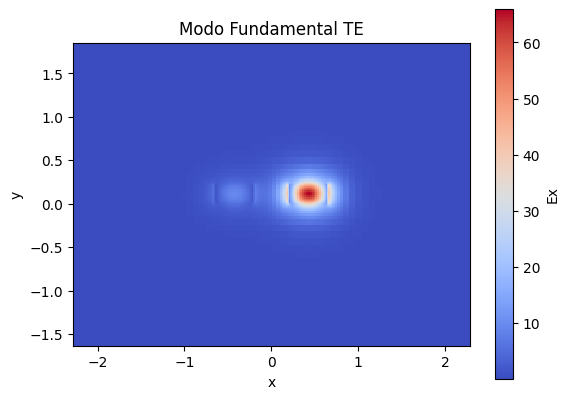

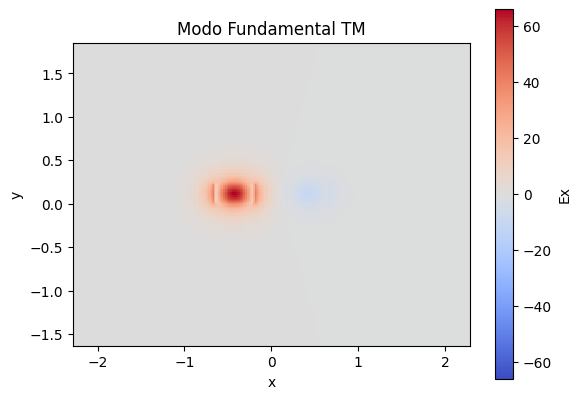

In [14]:
w = 0.45 # Waveguide width
h = 0.22 # Waveguide height 
wvl = 1.55 # Wavelength
gap = 0.4 # Gap entre los dos waveguides del acoplador

dcoupler_cs = gt.modes.WaveguideCoupler(
    core_width = (w, w), 
    slab_thickness = 0, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness = h, 
    gap = gap,
    core_material = 'si',
    clad_material = 'sio2', 
    wavelength = wvl, 
    num_modes = 2, # Number of modes to find
    cache_path = '.cache/', # Important! In order to save simulation time, set your cache Path!
    precision = 'double',
    max_grid_scaling = 1.5, # Parameters of the grid
    grid_resolution = 20 # Parameters of the grid
)

# Visualizamos el índice de refracción
dcoupler_cs.plot_index()
plt.title(f"Sección transversal del Acoplador (Gap = {gap} um)")
plt.show()

dcoupler_cs.plot_field(mode_index=0, field_name='Ex', value='real', cmap='coolwarm')
plt.title("Modo Fundamental TE")
plt.show()

dcoupler_cs.plot_field(mode_index=1, field_name='Ex', value='real', cmap='coolwarm')
plt.title("Modo Fundamental TM")
plt.show()

### 2.2. Sweep different gap values and coupling lengths.
### 2.3. Extract coupling coefficients (e.g., 0.5, 0.3, 0.23, etc.).

L_pi (100% acoplo) para Gap 0.4 um: 32.8818 um

--- LONGITUDES EXACTAS PARA SAX ---
 K = 0.5  --> L = 16.4409 um
 K = 0.3  --> L = 12.1337 um
 K = 0.23 --> L = 10.4704 um
 K = 0.17 --> L = 8.8964 um
 K = 0.05 --> L = 4.7207 um


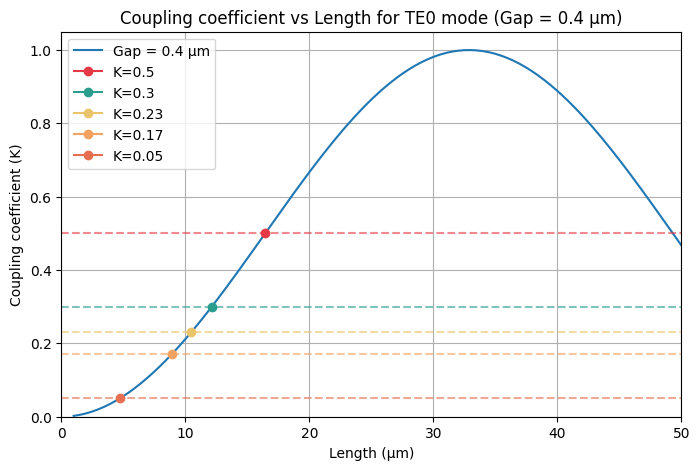

In [15]:
gap_fijo = 0.4
dcoupler_cs.gap = gap_fijo

# Cálculo de n_eff y L_pi
neff_even = dcoupler_cs.n_eff[0].real
neff_odd = dcoupler_cs.n_eff[1].real
L_pi_TE0 = 0.5 * wvl / (neff_even - neff_odd)

print(f"L_pi (100% acoplo) para Gap {gap_fijo} um: {L_pi_TE0:.4f} um\n")

# Barrido de Longitud L
length_values = np.linspace(1,50,200)

K_values = []
for length in length_values:
    K = np.sin(0.5 * np.pi * (length / L_pi_TE0))**2
    K_values.append(K)

# Gráfica
plt.figure(figsize=(8, 5))
plt.plot(length_values, K_values, label=f'Gap = {gap_fijo} µm')

objetivos = [0.5, 0.3, 0.23, 0.17, 0.05]
colores = ['#e63946', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51']

print("--- LONGITUDES EXACTAS PARA SAX ---")
for obj, col in zip(objetivos, colores):
    L_exacta = (2 * L_pi_TE0 / np.pi) * np.arcsin(np.sqrt(obj))
    print(f" K = {obj:<4} --> L = {L_exacta:.4f} um")
    plt.axhline(obj, color=col, linestyle='--', alpha=0.6)
    plt.plot(L_exacta, obj, marker='o', color=col, label=f'K={obj}')

plt.xlabel('Length (µm)')
plt.ylabel('Coupling coefficient (K)')
plt.title(f'Coupling coefficient vs Length for TE0 mode (Gap = {gap_fijo} µm)')
plt.xlim(0, max(length_values))
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

2026-05-17 17:11:13.971 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_1603419afa27ed52.npz.
2026-05-17 17:11:13.976 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_261db4b72fc32be4.npz.
2026-05-17 17:11:13.978 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_ded4cb8ab39471ab.npz.
2026-05-17 17:11:13.979 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_8624df0371ac4f19.npz.
2026-05-17 17:11:13.980 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_3696ec956eb0230f.npz.
2026-05-17 17:11:13.981 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_306c7733580fe28c.npz.
2026-05-17 17:11:13.983 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_a2076d76b6295812.npz.
2026-05-17 17:11:13.984 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

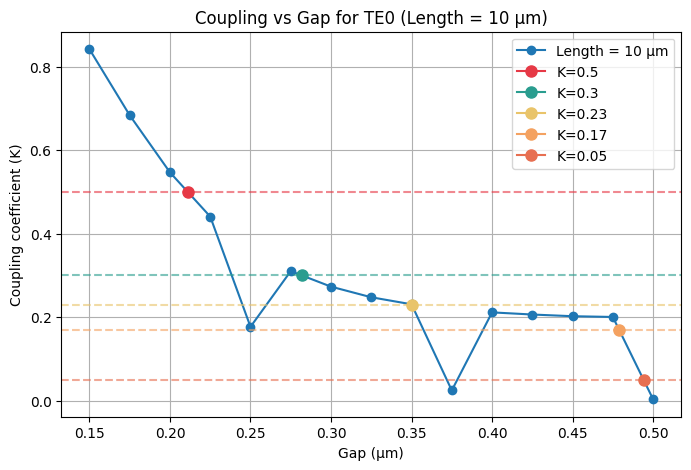

In [16]:
length = 10 # Longitud fija
wvl = 1.55 
gap_values = np.linspace(0.15, 0.5, 15) # Rango de gaps

K_values = []

for g in gap_values:

    dcoupler_cs = gt.modes.WaveguideCoupler(
    core_width = (w, w), 
    core_thickness = h, 
    gap = g,
    core_material = 'si',
    clad_material = 'sio2', 
    wavelength = wvl, 
    num_modes = 2,
    cache_path = '.cache/', 
    precision = 'double',
    max_grid_scaling = 1.5, 
    grid_resolution = 20 
)

    neff_even = dcoupler_cs.n_eff[0].real
    neff_odd = dcoupler_cs.n_eff[1].real
    
    # 2. Recalcular L_pi y K dependientes del nuevo gap
    L_pi_TE0 = 0.5 * wvl / (neff_even - neff_odd)
    K = np.sin(0.5 * np.pi * (length / L_pi_TE0))**2
    
    K_values.append(K)

# Convertir a arrays de numpy para poder operar con ellos
gap_values = np.array(gap_values)
K_values = np.array(K_values)

# Gráfica
plt.figure(figsize=(8, 5))
plt.plot(gap_values, K_values, marker='o', label=f'Length = {length} µm')

objetivos = [0.5, 0.3, 0.23, 0.17, 0.05]
colores = ['#e63946', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51']

print("\n--- GAPS EXACTOS PARA SAX (Interpolados) ---")
for obj, col in zip(objetivos, colores):
    # Interpolamos para encontrar el Gap exacto 
    # (Invertimos los arrays porque K baja a medida que el gap sube)
    gap_exacto = np.interp(obj, K_values[::-1], gap_values[::-1])
    print(f"K = {obj:<4} --> Gap = {gap_exacto:.4f} um")

    plt.axhline(obj, color=col, linestyle='--', alpha=0.6)
    plt.plot(gap_exacto, obj, marker='o', color=col, markersize=8, label=f'K={obj}')

plt.xlabel("Gap (µm)")
plt.ylabel("Coupling coefficient (K)")
plt.title(f"Coupling vs Gap for TE0 (Length = {length} µm)")
plt.legend()
plt.grid(True)
plt.show()

## 3. Cascaded MZI Filter and SAX Model

### 3.1. Extract the S-matrix from individual components

In [17]:
# Waveguide Model

def waveguide(wl=1.55, neff=3.48, length=10.0, loss=0.0) -> sax.SDict:
    """
    S-matrix de la guía. Calcula el desfase en función de la longitud 
    y de la longitud de onda, asumiendo un índice efectivo constante (sin dispersión),
    e incorpora la atenuación por pérdidas de propagación.
    """
    phase = 2 * np.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20) * jnp.exp(1j * phase) # loss(dB/um)
    wg_dict = sax.reciprocal({
            ("in0", "out0"): transmission,
    })
    return wg_dict

def waveguide_disp(wl=1.55, wvl_center=1.55 , neff_1550=2.3558, ng_1550=4.2933, length=10.0) -> sax.SDict:
    """
    S-matrix de la guía. Calcula el desfase en función de la longitud 
    y de la longitud de onda, usando la dispersión (n_g).
    """
    dwl = wl - wvl_center
    dn_dwl = - (ng_1550 - neff_1550) / wvl_center
    n_eff_wl = neff_1550 + dn_dwl * dwl
    
    # Fase acumulada: phi = (2 * pi * n_eff * L) / lambda
    phase = 2 * jnp.pi * n_eff_wl * length / wl
    transmission = jnp.exp(1j * phase)

    # Matriz S recíproca (2 puertos)
    wg_dict = sax.reciprocal({
            ("in0", "out0"): transmission,
    })
    return wg_dict


# Coupler Model

def coupler(coupling=0.5) -> sax.SDict:
    kappa = np.sqrt(coupling) # Amplitud transmisión directa (Bar)
    tau = np.sqrt(1 - coupling) # Amplitud transmisión cruzada (Cross)
    coupler_dict = sax.reciprocal({
            ("in0", "out0"): tau,
            ("in0", "out1"): 1j * kappa,
            ("in1", "out0"): 1j * kappa,
            ("in1", "out1"): tau,
    })
    return coupler_dict

### 3.2. Define two arms of the MZI with different lengths

In [18]:
lambda_0 = 1.55 # Longitud de onda central
FSR_S1 = 0.04  # FSR requerido para la etapa S1
FSR_S2 = 0.08  # FSR requerido para la etapa S2

neff = n_eff_TE 
ng = n_g_TE        

# Cálculo de la diferencia de longitud necesaria
delta_L_S1 = (lambda_0**2) / (ng * FSR_S1)
delta_L_S2 = (lambda_0**2) / (ng * FSR_S2)

# Definimos longitudes base para los brazos
Lu = 50 # µm (longitud del brazo corto)
Ld_S1 = Lu + delta_L_S1 # Longitud del brazo largo para S1
Ld_S2 = Lu + delta_L_S2 # Longitud del brazo largo para S2


print("=== ETAPA S1 (FSR = 40 nm) ===")
print(f"Longitud Lu fija : {Lu:.3f} µm")
print(f"Longitud Ld_S1 : {Ld_S1:.3f} µm")
print(f"Diferencia (Delta L): {delta_L_S1:.3f} µm")

print("=== ETAPA S2 (FSR = 80 nm) ===")
print(f"Longitud Lu fija : {Lu:.3f} µm")
print(f"Longitud Ld_S2: {Ld_S2:.3f} µm")
print(f"Diferencia (Delta L): {delta_L_S2:.3f} µm")

=== ETAPA S1 (FSR = 40 nm) ===
Longitud Lu fija : 50.000 µm
Longitud Ld_S1 : 63.990 µm
Diferencia (Delta L): 13.990 µm
=== ETAPA S2 (FSR = 80 nm) ===
Longitud Lu fija : 50.000 µm
Longitud Ld_S2: 56.995 µm
Diferencia (Delta L): 6.995 µm


### 3.3 Implement the phase condition as per Equation (1)

In [19]:
# Implementamos la condición de fase (Ecuación 1: m * lambda_0 = n_eff * delta_L)
m_S1 = (neff * delta_L_S1) / lambda_0
m_S2 = (neff * delta_L_S2) / lambda_0

# Forzamos a que m sea un número entero (redondeando)
m_S1_entero = np.round(m_S1)
m_S2_entero = np.round(m_S2)

# 4. Recalculamos el Delta L  usando el 'm' entero
delta_L_S1_exact = (m_S1_entero * lambda_0) / neff
delta_L_S2_exact = (m_S2_entero * lambda_0) / neff

print("--- AJUSTE FINO DEL FILTRO (ALINEACIÓN DE REJILLA CWDM) ---")
print("=== ETAPA S1 (FSR = 40 nm) ===")
print(f"1. Delta L base (solo FSR):        {delta_L_S1:.4f} um")
print(f"2. Orden de interferencia 'm':     {m_S1:.4f} -> Redondeado a {int(m_S1_entero)}")
print(f"3. Delta L EXACTO (Fase perfecta): {delta_L_S1_exact:.4f} um")
print("\n")
print("=== ETAPA S2 (FSR = 80 nm) ===")
print(f"1. Delta L base (solo FSR):        {delta_L_S2:.4f} um")
print(f"2. Orden de interferencia 'm':     {m_S2:.4f} -> Redondeado a {int(m_S2_entero)}")
print(f"3. Delta L EXACTO (Fase perfecta): {delta_L_S2_exact:.4f} um")

# Actualizamos las longitudes de los brazos para usarlas de aquí en adelante
Lu = 50
Ld_S1 = Lu + delta_L_S1_exact 
Ld_S2 = Lu + delta_L_S2_exact 

--- AJUSTE FINO DEL FILTRO (ALINEACIÓN DE REJILLA CWDM) ---
=== ETAPA S1 (FSR = 40 nm) ===
1. Delta L base (solo FSR):        13.9899 um
2. Orden de interferencia 'm':     21.2626 -> Redondeado a 21
3. Delta L EXACTO (Fase perfecta): 13.8171 um


=== ETAPA S2 (FSR = 80 nm) ===
1. Delta L base (solo FSR):        6.9950 um
2. Orden de interferencia 'm':     10.6313 -> Redondeado a 11
3. Delta L EXACTO (Fase perfecta): 7.2375 um


### 3.4. Simulate transmission spectrum and confirm free spectral range (FSR).
#### Para el caso de S1 (FSR=40nm)

In [20]:
# MZI

# Definimos la red de conexiones (Netlist) del MZI
mzi_netlist = {
    "instances": {
        "coup_in": "coupler", # Definimos el acoplador de entrada
        "coup_out": "coupler", # Definimos el acoplador de salida
        "wg_u": "waveguide", # Definimos el brazo superior
        "wg_d": "waveguide", # Definimos el brazo inferior
    },
    "connections": {
        "coup_in,out0": "wg_u,in0", # El out0 de coup_in va al in0 de wg_u
        "coup_in,out1": "wg_d,in0", # El out1 de coup_in va al in0 de wg_d
        "wg_u,out0": "coup_out,in0", # El out0 de wg_u va al in0 de coup_out
        "wg_d,out0": "coup_out,in1", # El out0 de wg_d va al in1 de coup_out
    },
    "ports": {
        "in0": "coup_in,in0", # El puerto de entrada del circuito se conecta al in0 de coup_in
        "in1": "coup_in,in1",  # El puerto de entrada del circuito se conecta al in1 de coup_in
        "out0": "coup_out,out0", # El puerto de salida del circuito se conecta al out0 de coup_out
        "out1": "coup_out,out1", # El puerto de salida del circuito se conecta al out1 de coup_out
    }
}

##### Caso usando la tabla de SOI con valores para longitudes de onda entre 1.53 y 1.57

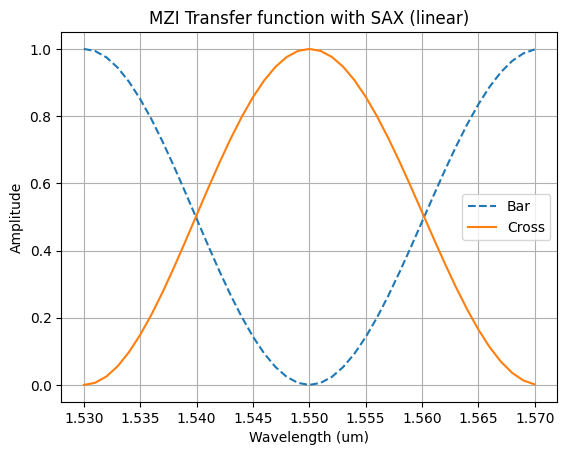

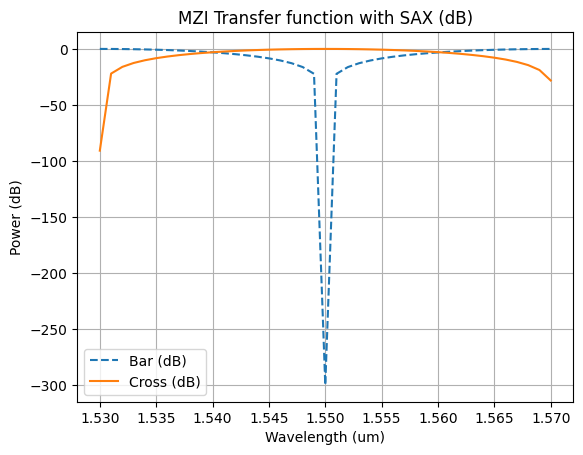

In [31]:
# Compilamos el circuito con SAX
mzi, info = sax.circuit(
    netlist=mzi_netlist, 
    models={"waveguide": waveguide, "coupler": coupler}
)

# Parámetros del modelo
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t') # SOI cross-section

wvl_sweep = SOI[:, 0]
neffu = SOI[:, 3] # neff TE mode   # Tiene configuración balanceada, es decir, con el mismo ancho (mismo índice efectivo) para la guía superior e inferior
neffd = SOI[:, 3] # neff TE mode

# Propagation loss
alphau = 0 # Sin pérdidas [dB/um]
alphad = 0 # Sin pérdidas [dB/um]

# Path length
Lu = Lu # µm (longitud del brazo corto)
Ld = Ld_S1 # Longitud del brazo largo para S1

# Coupling constant
K_a = np.full(wvl_sweep.shape, 0.5) # Hace un arrary con el mismo valor de acoplamiento (0.5) para todas las longitudes de onda
K_b = np.full(wvl_sweep.shape, 0.5)

# Ejecutamos el modelo del MZI
mzi_circuit = mzi(wl=wvl_sweep,
    coup_in = {"coupling": K_a},
    wg_d={"length": Ld, "neff": neffd, "loss": alphad},
    wg_u={"length": Lu, "neff": neffu, "loss": alphau},
    coup_out = {"coupling": K_b} )

H00 = mzi_circuit["in0", "out0"] # Transmisión directa (Bar) entrada in0
H10 = mzi_circuit["in0", "out1"] # Transmisión cruzada (Cross) entrada in0
H01 = mzi_circuit["in1", "out0"] # Transmisión cruzada (Cross) entrada in1
H11 = mzi_circuit["in1", "out1"] # Transmisión directa (Bar) entrada in1

H00_dB = 10 * jnp.log10(jnp.abs(H00)**2)
H10_dB = 10 * jnp.log10(jnp.abs(H10)**2)
H01_dB = 10 * jnp.log10(jnp.abs(H01)**2)
H11_dB = 10 * jnp.log10(jnp.abs(H11)**2)

# Plot
plt.figure()
plt.plot(wvl_sweep, np.abs(H00)**2, linestyle='--', label='Bar')
plt.plot(wvl_sweep, np.abs(H10)**2, linestyle='-', label='Cross')
plt.xlabel('Wavelength (um)')
plt.ylabel('Amplitude')
plt.title('MZI Transfer function with SAX (linear)')
plt.legend()
plt.grid(True)

plt.figure()
plt.plot(wvl_sweep, H00_dB, linestyle='--', label='Bar (dB)')
plt.plot(wvl_sweep, H10_dB, linestyle='-', label='Cross (dB)')
plt.xlabel('Wavelength (um)')
plt.ylabel('Power (dB)')
plt.title('MZI Transfer function with SAX (dB)')
plt.legend()
plt.grid(True)
plt.show()

##### Caso usando aproximación lineal de dispersión (con ng) para longitudes de onda entre 1.5 y 1.6

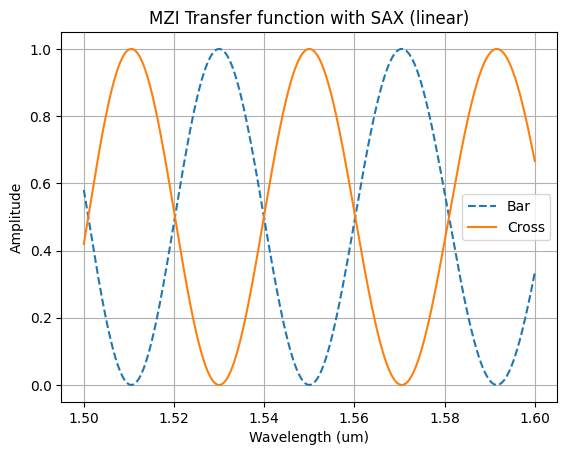

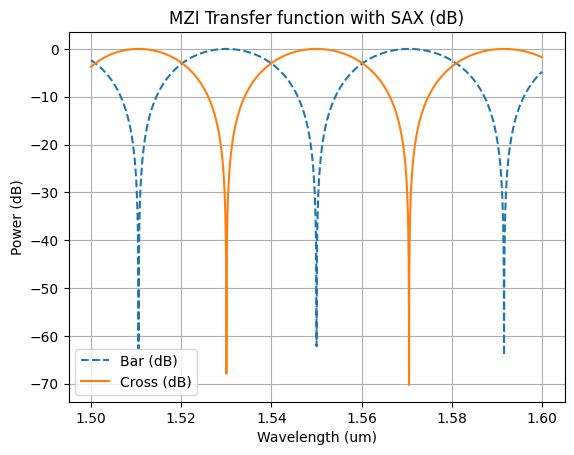

In [ ]:
# Compilamos el circuito con SAX
mzi, info = sax.circuit(
    netlist=mzi_netlist, 
    models={"waveguide": waveguide_disp, "coupler": coupler}
)

# Parámetros del modelo
wvl_sweep = np.linspace(1.5, 1.6, 5000)
neffu = n_eff_TE # Configuración balanceada. Es decir, con el mismo ancho (mismo índice efectivo) para la guía superior e inferior
neffd = n_eff_TE
ng_u = n_g_TE 
ng_d = n_g_TE

# Propagation loss
alphau = 0 # Sin pérdidas [dB/um]
alphad = 0 # Sin pérdidas [dB/um]

# Path length
Lu = Lu # µm (longitud del brazo corto)
Ld = Ld_S1 # Longitud del brazo largo para S1

# Coupling constant
K_a = np.full(wvl_sweep.shape, 0.5) # Hace un arrary con el mismo valor de acoplamiento (0.5) para todas las longitudes de onda
K_b = np.full(wvl_sweep.shape, 0.5)


# Ejecutamos el modelo del MZI
mzi_circuit = mzi(wl=wvl_sweep,
    coup_in = {"coupling": K_a},
    wg_d={"length": Ld, "neff_1550": neffd, "ng_1550": ng_d},
    wg_u={"length": Lu, "neff_1550": neffu, "ng_1550": ng_u},
    coup_out = {"coupling": K_b} )

H00 = mzi_circuit["in0", "out0"] # Transmisión directa (Bar) entrada in0
H10 = mzi_circuit["in0", "out1"] # Transmisión cruzada (Cross) entrada in0
H01 = mzi_circuit["in1", "out0"] # Transmisión cruzada (Cross) entrada in1
H11 = mzi_circuit["in1", "out1"] # Transmisión directa (Bar) entrada in1

H00_dB = 10 * jnp.log10(jnp.abs(H00)**2)
H10_dB = 10 * jnp.log10(jnp.abs(H10)**2)
H01_dB = 10 * jnp.log10(jnp.abs(H01)**2)
H11_dB = 10 * jnp.log10(jnp.abs(H11)**2)

# Plot
plt.figure()
plt.plot(wvl_sweep, np.abs(H00)**2, linestyle='--', label='Bar')
plt.plot(wvl_sweep, np.abs(H10)**2, linestyle='-', label='Cross')
plt.xlabel('Wavelength (um)')
plt.ylabel('Amplitude')
plt.title('MZI Transfer function with SAX (linear)')
plt.legend()
plt.grid(True)

plt.figure()
plt.plot(wvl_sweep, H00_dB, linestyle='--', label='Bar (dB)')
plt.plot(wvl_sweep, H10_dB, linestyle='-', label='Cross (dB)')
plt.xlabel('Wavelength (um)')
plt.ylabel('Power (dB)')
plt.title('MZI Transfer function with SAX (dB)')
plt.legend()
plt.grid(True)
plt.show()

### 3.5. Create SAX model connecting multiple MZIs in series using the designed directional couplers

In [24]:
# Hacer un barrido de longitudes. que confifuración de L1 y L2 
#Recalcular als longitudes para obtener las FSR que de piden en S1 y en S2. Se fija L1 y se halla L2 (mediante una fórmula)